In [1]:
import pandas as pd

# df_raw = pd.read_excel(r'../data/credit_risk_dataset_v2_sample10k.xlsx', sheet_name='Customer Data')
# switched to parquet for faster loading
df_raw = pd.read_parquet(r'../data/credit_risk_dataset_v2.parquet')
print(df_raw.shape)

(100000, 538)


In [2]:
df_raw.head(5)

,customer_id,risk_attribute_770487,risk_attribute_216739,risk_attribute_126225,risk_attribute_877572,risk_attribute_388389,risk_attribute_356787,risk_attribute_334053,risk_attribute_246316,risk_attribute_872246,...,risk_attribute_815198,risk_attribute_361650,risk_attribute_799330,risk_attribute_207786,risk_attribute_470858,risk_attribute_918011,risk_attribute_687080,risk_attribute_526117,risk_attribute_750810,risk_attribute_885884
0,CUST_0000001,0,0,0,0,0,0,0,0,0,...,3,129040,0,1.2165,0,5,600,0,28,0
1,CUST_0000002,83,16,27,44,88,18,21,95,60,...,7,209523,31881,2.0054,2,3,8,1,27,0
2,CUST_0000003,0,0,0,0,0,0,0,0,0,...,6,291204,16642,2.1153,0,5,600,1,31,0
3,CUST_0000004,0,0,0,0,0,0,0,0,0,...,4,124421,242679,1.1624,0,5,600,2,62,0
4,CUST_0000005,0,0,0,0,0,0,0,0,0,...,2,122404,102981,0.0000,0,5,600,1,67,0


In [3]:
#target columns
# a customer flagged `bad = 1` if any of three risk attributes cross a threshold (one ≥ 8, two others > 0), else `0`
df_raw['bad'] = (
    (df_raw['risk_attribute_383060'] >= 8) |
    (df_raw['risk_attribute_274389'] > 0) |
    (df_raw['risk_attribute_272634'] > 0)
).astype(int)
#  value_counts and mean show the class balance and the resulting bad rate.
print(df_raw['bad'].value_counts())
print("Bad rate:", df_raw['bad'].mean())
# the three columns used to *build* the label are stored in `leakage_cols` and dropped from the features otherwise the model could cheat by learning the exact rule that defined the target. `customer_id` (an identifier, not a predictor) is also dropped.
leakage_cols = ['risk_attribute_383060', 'risk_attribute_274389', 'risk_attribute_272634']
X = df_raw.drop(columns=['customer_id', 'bad'] + leakage_cols)
y = df_raw['bad']
# The result is `X` (features) and `y` (target). The final line confirms there are no missing values.
print("X shape:", X.shape, "y shape:", y.shape)
print("Missing Values in dataset:", X.isnull().sum().sum())

bad
0    98552
1     1448
Name: count, dtype: int64
Bad rate: 0.01448
X shape: (100000, 534) y shape: (100000,)
Missing Values in dataset: 0


In [4]:
#train test split 80/20
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.mean(), y_test.mean())

(80000, 534) (20000, 534)
0.014475 0.0145


In [5]:
# --- imports + shared setup ---
# The baseline model cells were removed, which took these imports (and `spw`) with them.
# This cell restores what the rest of the notebook depends on.
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV,
)
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_curve,
    classification_report, confusion_matrix,
)

# used by the leakage sweep below
spw = (y == 0).sum() / (y == 1).sum()
print("scale_pos_weight (original label):", round(spw, 2))

scale_pos_weight (original label): 68.06


In [6]:
# dd = pd.read_excel(r'../data/credit_risk_dataset_v2_sample10k.xlsx', sheet_name='Data Dictionary')
# col2cat = dd.set_index('Column Name')['Category'].to_dict()
# col2def = dd.set_index('Column Name')['Definition'].to_dict()
# print(dd.shape)
# print(dd['Category'].value_counts().head(15).to_string())

dd = pd.read_parquet(r'../data/credit_risk_data_dictionary.parquet')
col2cat = dd.set_index('Column Name')['Category'].to_dict()
col2def = dd.set_index('Column Name')['Definition'].to_dict()

In [7]:
# What the three label-source columns
for c in leakage_cols:
    print(f"{c}\n  category: {col2cat[c]}\n  def     : {col2def[c]}\n")

c = 'risk_attribute_671412'
print(f"{c}\n  category: {col2cat[c]}\n  def     : {col2def[c]}")

risk_attribute_383060
  category: Worst Status Codes
  def     : Worst status code ever on a all trades

risk_attribute_274389
  category: Collections and Derogatory Metrics
  def     : Total number of charge-off trades

risk_attribute_272634
  category: Public Records and Bankruptcy
  def     : Total number of public record bankruptcies

risk_attribute_671412
  category: Delinquency Percentages
  def     : Percentage of all trades that are never delinquent or derogatory


In [8]:
# how much to remove before the label stops being reconstructible?
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

single_auc = {}
for c in X.columns:
    if X[c].nunique() < 2:
        continue
    a = roc_auc_score(y, X[c])
    single_auc[c] = max(a, 1 - a)
single_auc = pd.Series(single_auc)

rows = []
for thr in [0.95, 0.90, 0.80, 0.70, 0.60, 0.55]:
    drop = single_auc[single_auc > thr].index
    Xd = X.drop(columns=drop)
    a, b, c_, d = train_test_split(Xd, y, test_size=.2, random_state=42, stratify=y)
    mm = XGBClassifier(n_estimators=300, learning_rate=.05, max_depth=4, subsample=.8,
                       colsample_bytree=.8, min_child_weight=5, scale_pos_weight=spw,
                       eval_metric='aucpr', random_state=42, n_jobs=-1).fit(a, c_)
    pp = mm.predict_proba(b)[:, 1]
    rows.append({'drop_above_auc': thr, 'n_dropped': len(drop), 'n_left': Xd.shape[1],
                 'roc_auc': roc_auc_score(d, pp), 'pr_auc': average_precision_score(d, pp)})

print(pd.DataFrame(rows).round(4).to_string(index=False))

 drop_above_auc  n_dropped  n_left  roc_auc  pr_auc
           0.95         19     515   1.0000  1.0000
           0.90        138     396   1.0000  1.0000
           0.80        318     216   0.9996  0.9943
           0.70        418     116   0.9864  0.6954
           0.60        475      59   0.8227  0.3661
           0.55        521      13   0.6251  0.1412


In [ ]:
# --- feature filter (corrected) ---
# The previous version of this cell had two bugs, both of which inflated PR-AUC to 0.917:
#
#   1. `bad` (the original 3-event label, written into df_raw by the label cell) survived
#      the filter, because col2cat.get('bad') is None and None is not in the category set.
#      It was the #2 feature at 14.6% of gain. `bad` is 1 whenever bankruptcy is 1.
#
#   2. Category labels do not track content. "Total dollar amount in derogatory status"
#      is filed under Balance Metrics; "trade types with at least one delinquency ever"
#      under Miscellaneous. 47 such columns passed the category filter.
#
# Fix: filter on definition TEXT as well as category, and drop anything that is not a
# documented bureau attribute.
import re

TARGET_COL = 'risk_attribute_272634'   # total public record bankruptcies

DEROGATORY_CATEGORIES = {
    'Delinquency Percentages',
    'Delinquency Counts – 30 Days',
    'Delinquency Counts – 60 Days and Severe',
    'Worst Status Codes',
    'Collections and Derogatory Metrics',
    'Months Since Delinquency',
    'Public Records and Bankruptcy',
    'Additional Delinquency Severity and Recurrence',
    'Derived and Composite Risk Indicators',
    'Financial Stress and Hardship Indicators',
    'Payment History and Behavior',
}

DEROG_TERMS = re.compile(
    r'delinq|derog|charge[ -]?off|charged[ -]?off|collection|bankrupt|public record|'
    r'dispute|repossess|foreclos|written[ -]off|past due|\bdpd\b|worst status|'
    r'ever 30|ever 60|ever 90|ever 120|30\+|60\+|90\+',
    re.I,
)

# "excluding derogatory" is a scope qualifier, not derogatory content. It still leaks
# indirectly: the model can difference such a column against its unqualified twin to
# recover the derogatory amount. Set to False to keep them and see how much it matters.
DROP_SCOPE_QUALIFIED = True
SCOPE = re.compile(r'\b(?:excluding|excl\.?|except|other than)\b[^,;.]*', re.I)

_txt = (dd['Definition'].fillna('') + ' | ' + dd['Valid Values / Notes'].fillna(''))
_content = _txt.apply(lambda t: bool(DEROG_TERMS.search(SCOPE.sub(' ', t))))
_scope   = _txt.apply(lambda t: bool(DEROG_TERMS.search(t))) & ~_content

content_cols = set(dd.loc[_content, 'Column Name'])
scope_cols   = set(dd.loc[_scope,   'Column Name'])
documented   = set(dd['Column Name'])          # anything not here is not a bureau attribute

y_v2 = (df_raw[TARGET_COL] > 0).astype(int)

dropped = {'not a documented attribute': [], 'derogatory category': [],
           'derogatory in definition': [], 'scope-qualified': []}
clean_cols = []
for c in df_raw.columns:
    if c not in documented:                       # customer_id, bad, anything else added
        dropped['not a documented attribute'].append(c)
    elif col2cat.get(c) in DEROGATORY_CATEGORIES:
        dropped['derogatory category'].append(c)
    elif c in content_cols:
        dropped['derogatory in definition'].append(c)
    elif c in scope_cols and DROP_SCOPE_QUALIFIED:
        dropped['scope-qualified'].append(c)
    else:
        clean_cols.append(c)

X_v2 = df_raw[clean_cols]

for reason, cols in dropped.items():
    print(f"dropped ({reason}): {len(cols)}")
    if reason == 'not a documented attribute':
        print(f"    -> {cols}")
print(f"\nfeatures kept: {X_v2.shape[1]}   (previous buggy run: 309)")
print(f"positives: {int(y_v2.sum())}   rate: {y_v2.mean():.4f}")

assert 'bad' not in X_v2.columns, "label leaked into features"
assert TARGET_COL not in X_v2.columns, "target leaked into features"
print("\nassertions passed")

In [10]:
#residual leakage audit
# Run this BEFORE trusting any score. If a single feature separates the target almost
# perfectly on its own, the filter has missed something and the model result is fiction.
_auc = {}
for c in X_v2.columns:
    v = X_v2[c]
    if v.nunique() < 2:
        continue
    a = roc_auc_score(y_v2, v)
    _auc[c] = max(a, 1 - a)
_auc = pd.Series(_auc).sort_values(ascending=False)

print("highest single-feature AUC vs target:\n")
audit = pd.DataFrame({
    "auc": _auc.head(10).round(4),
    "category": [col2cat.get(c) for c in _auc.head(10).index],
    "definition": [str(col2def.get(c))[:65] for c in _auc.head(10).index],
})
print(audit.to_string())

worst = _auc.iloc[0]
print(f"\nmax single-feature AUC: {worst:.4f}")
if worst > 0.90:
    print("  -> Still leaking. Inspect the definition above and extend DEROG_TERMS.")
elif worst > 0.80:
    print("  -> Borderline. Worth reading the top few definitions before trusting results.")
else:
    print("  -> No single feature dominates. Reasonable to proceed.")

highest single-feature AUC vs target:

                          auc                                    category                                                         definition
risk_attribute_216970  0.9501               Credit Age and History Length  Average number of months since credit card trades were opened inc
risk_attribute_564656  0.9458            Credit Card and Bankcard Metrics  Percentage of open credit card trades where only minimum payment 
risk_attribute_789305  0.9450  Installment, Revolving, and Retail Metrics                    Number of months since oldest installment trade
risk_attribute_456699  0.9445               Credit Age and History Length  Average number of months since all trades were opened including i
risk_attribute_204837  0.9444          Personal Finance and Student Loans  Number of months since the most recent personal finance inquiry (
risk_attribute_103717  0.9436       Credit File Characteristics and Flags  Percentage of trades with balance-to-lim

In [10]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X_v2, y_v2, test_size=0.2, random_state=42, stratify=y_v2
)
spw_v2 = (y2_train == 0).sum() / (y2_train == 1).sum()

xgb_v2 = XGBClassifier(
    n_estimators=600,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.6,
    min_child_weight=10,
    reg_lambda=5.0,
    scale_pos_weight=spw_v2,
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1,
)
xgb_v2.fit(X2_train, y2_train)

proba_v2 = xgb_v2.predict_proba(X2_test)[:, 1]
pr = average_precision_score(y2_test, proba_v2)
floor = y2_test.mean()

print("ROC-AUC : %.4f" % roc_auc_score(y2_test, proba_v2))
print("PR-AUC  : %.4f" % pr)
print("Floor   : %.4f  (random guessing)" % floor)
print("Lift    : %.1fx over random" % (pr / floor))

ROC-AUC : 0.9992
PR-AUC  : 0.9171
Floor   : 0.0065  (random guessing)
Lift    : 141.1x over random


In [11]:
# Cross-validated only around 15 positives land in a single test split, so one number is unreliable.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_v2 = cross_val_score(xgb_v2, X_v2, y_v2, cv=cv, scoring="average_precision", n_jobs=-1)

print("Fold PR-AUCs:", np.round(cv_v2, 4))
print("Mean: %.4f  (+/- %.4f)" % (cv_v2.mean(), cv_v2.std()))

Fold PR-AUCs: [0.884  0.9061 0.9265 0.8772 0.8883]
Mean: 0.8964  (+/- 0.0178)


Best-F1 threshold: 0.9795
  precision 0.914   recall 0.815   F1 0.862


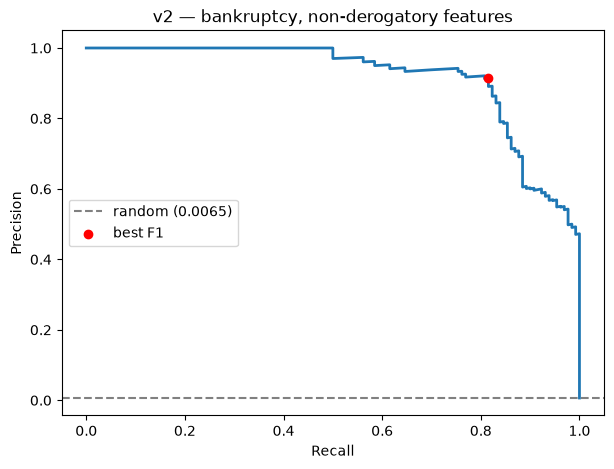

[[19860    10]
 [   24   106]]
              precision    recall  f1-score   support

           0      0.999     0.999     0.999     19870
           1      0.914     0.815     0.862       130

    accuracy                          0.998     20000
   macro avg      0.956     0.907     0.930     20000
weighted avg      0.998     0.998     0.998     20000



In [12]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

prec, rec, thresh = precision_recall_curve(y2_test, proba_v2)
f1 = 2 * prec * rec / (prec + rec + 1e-9)
best = f1.argmax()

print("Best-F1 threshold: %.4f" % thresh[min(best, len(thresh) - 1)])
print("  precision %.3f   recall %.3f   F1 %.3f" % (prec[best], rec[best], f1[best]))

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(rec, prec, lw=2)
ax.axhline(floor, ls="--", c="grey", label="random (%.4f)" % floor)
ax.scatter(rec[best], prec[best], c="red", zorder=5, label="best F1")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("v2 — bankruptcy, non-derogatory features")
ax.legend(); plt.show()

pred_v2 = (proba_v2 >= thresh[min(best, len(thresh) - 1)]).astype(int)
print(confusion_matrix(y2_test, pred_v2))
print(classification_report(y2_test, pred_v2, digits=3))

In [13]:
imp_v2 = pd.Series(xgb_v2.feature_importances_, index=X_v2.columns).sort_values(ascending=False)

top = pd.DataFrame({
    "gain": imp_v2.head(15).round(4),
    "category": [col2cat.get(c) for c in imp_v2.head(15).index],
    "definition": [str(col2def.get(c))[:70] for c in imp_v2.head(15).index],
})
print("top-1 share of gain: %.1f%%  (baseline was 37.7%%)" % (100 * imp_v2.iloc[0] / imp_v2.sum()))
print(top.to_string())

top-1 share of gain: 23.3%  (baseline was 37.7%)
                         gain                                        category                                                              definition
risk_attribute_178898  0.2332      Supplemental Bankcard and Revolving Detail  Number of months since the last time consumer had zero balance on all 
bad                    0.1464                                             NaN                                                                    None
risk_attribute_470858  0.1350  Miscellaneous and Supplemental Risk Attributes          Total number of trade types with at least one delinquency ever
risk_attribute_814825  0.0962                                 Balance Metrics                  Total dollar amount in derogatory status on all trades
risk_attribute_687080  0.0656  Miscellaneous and Supplemental Risk Attributes      Average months since derogatory event across all derogatory trades
risk_attribute_322086  0.0586            Trade Coun

In [ ]:
#hyperparameter search
from scipy.stats import loguniform, randint, uniform

USE_GPU = True   # set True if you have an NVIDIA GPU
N_CANDIDATES = 100
N_JOBS = 14        # set to your physical core count, not -1

base = XGBClassifier(
    eval_metric="aucpr",
    random_state=42,
    tree_method="hist",
    device="cuda" if USE_GPU else "cpu",
    n_jobs=1,     
)

param_dist = {
    "n_estimators":     randint(200, 1200),
    "learning_rate":    loguniform(0.01, 0.2),
    "max_depth":        randint(2, 7),
    "min_child_weight": randint(1, 30),
    "subsample":        uniform(0.6, 0.4),      # 0.6 - 1.0
    "colsample_bytree": uniform(0.3, 0.7),      # 0.3 - 1.0
    "reg_lambda":       loguniform(0.1, 50.0),
    "reg_alpha":        loguniform(1e-3, 10.0),
    "gamma":            loguniform(1e-4, 5.0),
    # searched, not fixed at n_neg/n_pos
    "scale_pos_weight": loguniform(1.0, spw_v2 * 2),
}

search = RandomizedSearchCV(
    base,
    param_distributions=param_dist,
    n_iter=N_CANDIDATES,
    scoring="average_precision",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=69),
    n_jobs=N_JOBS,
    refit=True,
    random_state=69,
    verbose=1,
    return_train_score=False,
)

search.fit(X2_train, y2_train)   # test set deliberately untouched

print("\nbest CV PR-AUC: %.4f" % search.best_score_)
for k, v in sorted(search.best_params_.items()):
    print(f"  {k:18} {v:.4f}" if isinstance(v, float) else f"  {k:18} {v}")

Fitting 5 folds for each of 100 candidates, totalling 500 fits

best CV PR-AUC: 0.9242
  colsample_bytree   0.6920
  gamma              0.1189
  learning_rate      0.0448
  max_depth          6
  min_child_weight   1
  n_estimators       292
  reg_alpha          0.1448
  reg_lambda         4.7861
  scale_pos_weight   85.6669
  subsample          0.8175


In [15]:
xgb_tuned = search.best_estimator_
proba_tuned = xgb_tuned.predict_proba(X2_test)[:, 1]

pr_v2    = average_precision_score(y2_test, proba_v2)
pr_tuned = average_precision_score(y2_test, proba_tuned)
floor    = y2_test.mean()

results = pd.DataFrame([
    {"model": "v2 (hand-tuned)", "cv_pr_auc": cv_v2.mean(),
     "heldout_pr_auc": pr_v2,    "heldout_roc_auc": roc_auc_score(y2_test, proba_v2)},
    {"model": "v2 (searched)",   "cv_pr_auc": search.best_score_,
     "heldout_pr_auc": pr_tuned, "heldout_roc_auc": roc_auc_score(y2_test, proba_tuned)},
])
results["lift_vs_random"] = (results["heldout_pr_auc"] / floor).round(1)
results["cv_minus_heldout"] = (results["cv_pr_auc"] - results["heldout_pr_auc"]).round(4)

print("random-guessing floor: %.4f\n" % floor)
print(results.round(4).to_string(index=False))

gap = search.best_score_ - pr_tuned
print("\nwinner's-curse gap: %+.4f" % gap)
if gap > 2 * cv_v2.std():
    print("CV score is optimistic by more than 2 CV std devs.")
    print("Report the held-out number, not best_score_.")
if pr_tuned <= pr_v2:
    print("Search did NOT beat the hand-tuned model on held-out data.")
    print("Expected on the 10k sample. Keep the simpler model.")

random-guessing floor: 0.0065

          model  cv_pr_auc  heldout_pr_auc  heldout_roc_auc  lift_vs_random  cv_minus_heldout
v2 (hand-tuned)     0.8964          0.9171           0.9992           141.1           -0.0206
  v2 (searched)     0.9242          0.9211           0.9993           141.7            0.0031

winner's-curse gap: +0.0031


c:\Users\tobia\Desktop\School\6156\Github Repo\credit_risk_classification\.venv\Lib\site-packages\xgboost\core.py:553: UserWarning: [19:18:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


In [16]:
#search surface flatness
cvres = pd.DataFrame(search.cv_results_)
top = cvres.nsmallest(20, "rank_test_score")[
    ["rank_test_score", "mean_test_score", "std_test_score",
     "param_max_depth", "param_min_child_weight", "param_scale_pos_weight",
     "param_learning_rate", "param_reg_lambda"]
]
print(top.round(4).to_string(index=False))

spread = top["mean_test_score"].max() - top["mean_test_score"].min()
print("\nspread across top-20: %.4f   typical fold std: %.4f"
      % (spread, top["std_test_score"].mean()))
if spread < top["std_test_score"].mean():
    print("Top-20 are within noise of each other; ranking not meaningful.")

 rank_test_score  mean_test_score  std_test_score  param_max_depth  param_min_child_weight  param_scale_pos_weight  param_learning_rate  param_reg_lambda
               1           0.9242          0.0163                6                       1                 85.6669               0.0448            4.7861
               2           0.9223          0.0161                6                       3                177.9130               0.0237            0.1266
               3           0.9222          0.0184                5                       1                  5.5479               0.0134            5.4621
               4           0.9212          0.0202                6                       6                  6.9283               0.0239            0.7500
               5           0.9210          0.0170                5                       2                276.1669               0.0369            0.2549
               6           0.9188          0.0199                6          